# Mix audio sound classifcation with heart sound classification and lung sound classification. 

Use the same model architecture and training process for all three tasks. Compare the performance of the models on each task and analyze the results.

In [9]:
# imports
import pandas as pd
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
heart_model = joblib.load("../heart_sound_classification/heart_model.pkl")
lung_model = joblib.load("../lung_sound_classification/lung_model.pkl")

label_encoder_heart = joblib.load("../heart_sound_classification/label_encoder_heart.pkl")
label_encoder_lung = joblib.load("../lung_sound_classification/label_encoder_lung.pkl")

print("Models loaded.")

Models loaded.


In [11]:
# load mix.csv

mix_df = pd.read_csv("../dataset/Mix.csv")

print(mix_df.head())
print("Total mixed recordings:", len(mix_df))


  Gender      Heart Sound Type  Lung Sound Type Location Heart Sound ID  \
0      F  Late Systolic Murmur          Rhonchi     LUSB          H0001   
1      F                    S3           Normal      RLA          H0002   
2      M   Atrial Fibrillation           Normal      LMA          H0003   
3      F                    S3  Coarse Crackles     Apex          H0004   
4      M              AV Block    Fine Crackles     RUSB          H0005   

  Lung Sound ID Mixed Sound ID  
0         L0001          M0001  
1         L0002          M0002  
2         L0003          M0003  
3         L0004          M0004  
4         L0005          M0005  
Total mixed recordings: 145


In [12]:
# feature extraction function
def extract_features(path):

    audio, sr = librosa.load(path, sr=22050)
    audio = audio / (np.max(np.abs(audio)) + 1e-9)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    chroma = np.mean(librosa.feature.chroma_stft(y=audio, sr=sr), axis=1)
    contrast = np.mean(librosa.feature.spectral_contrast(y=audio, sr=sr), axis=1)

    zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))
    rms = np.mean(librosa.feature.rms(y=audio))

    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))

    return np.hstack([
        mfcc_mean,
        mfcc_std,
        chroma,
        contrast,
        zcr,
        rms,
        centroid,
        bandwidth,
        rolloff
    ])

In [ ]:
# run evaluatiaon
results = []

mix_folder = "../dataset/Mix"

for _, row in mix_df.iterrows():

    mix_id = row["Mixed Sound ID"]
    mix_path = os.path.join(mix_folder, mix_id + ".wav")

    if not os.path.exists(mix_path):
        print("Missing:", mix_path)
        continue

    try:
        features = extract_features(mix_path).reshape(1, -1)

        # SVM predictions
        heart_pred = heart_model.predict(features)[0]
        lung_pred = lung_model.predict(features)[0]

        results.append({
            "Mix_ID": mix_id,

            "True_Heart": row["Heart Sound Type"],
            "Pred_Heart": heart_pred,

            "True_Lung": row["Lung Sound Type"],
            "Pred_Lung": lung_pred
        })

    except Exception as e:
        print("Error:", mix_path, e)

print("Evaluation complete")

Evaluation complete


In [14]:
# create results dataframe
results_df = pd.DataFrame(results)

results_df.head()

,Mix_ID,True_Heart,Pred_Heart,True_Lung,Pred_Lung
0,M0001,Late Systolic Murmur,4,Rhonchi,2
1,M0002,S3,4,Normal,2
2,M0003,Atrial Fibrillation,4,Normal,2
3,M0004,S3,4,Coarse Crackles,2
4,M0005,AV Block,4,Fine Crackles,2


In [15]:
# save the reuslts
results_df.to_csv(
    "mix_evaluation_results.csv",
    index=False
)

print("Results saved.")

Results saved.


In [ ]:
# heart sound accuracy on MIX
print("\nHeart Accuracy:")
print(accuracy_score(results_df["True_Heart"], results_df["Pred_Heart"]))

ValueError: Mix of label input types (string and number); Got ['AV Block' 'Atrial Fibrillation' 'Early Systolic Murmur'
 'Late Diastolic Murmur' 'Late Systolic Murmur' 'Mid Systolic Murmur'
 'Normal' 'S3' 'S4' 'Tachycardia'] and [4].

In [ ]:
# Lung sound accuracy on Mix
lung_acc = accuracy_score(
    results_df["True_Lung"],
    results_df["Pred_Lung"]
)

print(
    "Lung Accuracy on MIX:",
    round(lung_acc, 4)
)

Lung Accuracy on MIX: 0.3931


In [ ]:
# heart sound classification report
print("\nHEART REPORT")
print(classification_report(
    results_df["True_Heart"],
    results_df["Pred_Heart"],
    zero_division=0
))


HEART REPORT ON MIX
                       precision    recall  f1-score   support

             AV Block       0.00      0.00      0.00        13
  Atrial Fibrillation       0.00      0.00      0.00        15
Early Systolic Murmur       0.11      0.38      0.17        13
Late Diastolic Murmur       0.00      0.00      0.00        13
 Late Systolic Murmur       0.21      0.82      0.33        17
  Mid Systolic Murmur       0.08      0.07      0.07        14
               Normal       0.23      0.23      0.23        13
                   S3       0.20      0.07      0.10        15
                   S4       0.00      0.00      0.00        16
          Tachycardia       0.00      0.00      0.00        16

             accuracy                           0.17       145
            macro avg       0.08      0.16      0.09       145
         weighted avg       0.08      0.17      0.09       145



In [ ]:
# lung sound classification report
print("\nLUNG REPORT")
print(classification_report(
    results_df["True_Lung"],
    results_df["Pred_Lung"],
    zero_division=0
))


LUNG REPORT ON MIX
                 precision    recall  f1-score   support

Coarse Crackles       0.24      0.21      0.22        19
  Fine Crackles       0.57      0.18      0.28        22
         Normal       0.54      0.46      0.50        28
    Pleural Rub       0.50      0.20      0.29        25
        Rhonchi       0.37      0.30      0.33        23
       Wheezing       0.35      0.86      0.50        28

       accuracy                           0.39       145
      macro avg       0.43      0.37      0.35       145
   weighted avg       0.43      0.39      0.37       145



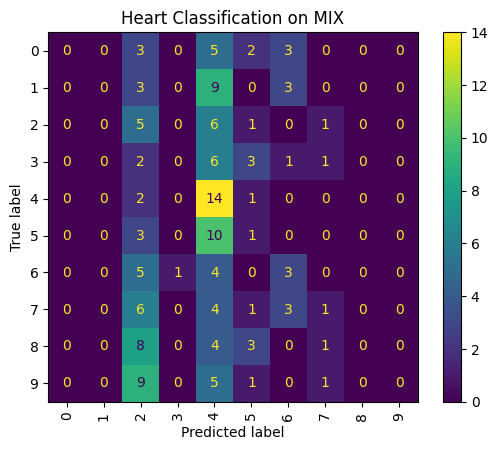

In [ ]:
# heart confusion maatrix
cm1 = confusion_matrix(
    results_df["True_Heart"],
    results_df["Pred_Heart"]
)

ConfusionMatrixDisplay(cm1).plot(xticks_rotation=90)
plt.title("Heart Classification (SVM) on MIX")
plt.show()

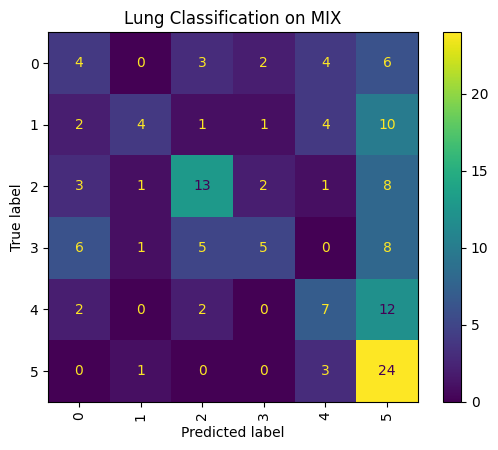

In [ ]:
# lung confusion matrix
cm2 = confusion_matrix(
    results_df["True_Lung"],
    results_df["Pred_Lung"]
)

ConfusionMatrixDisplay(cm2).plot(xticks_rotation=90)
plt.title("Lung Classification (SVM) on MIX")
plt.show()